# Day5 · 블록2 · YOLOv8 추론 & Kalman Filter 개요 실습

> **강의자료**: `강의자료/05.02.YOLO-Kalman.md`

| Part | 주제 |
|------|------|
| Part 1 | 객체 탐지와 YOLOv8 개념 |
| Part 2 | YOLOv8 설치 및 기본 사용법 |
| Part 3 | YOLOv8 실전 활용 + 최적화 |
| Part 4 | Kalman Filter 개념 개요 |
| Part 5 | 칼만 필터 — 원리 깊이 이해하기 |
| Part 6 | 체크리스트 |

**실습 목적**: YOLOv8로 실시간 객체를 탐지하고, 칼만 필터를 직접 구현하여 탐지 결과를 안정화하는 파이프라인을 구축합니다.

---
## Part 1: 객체 탐지와 YOLOv8 개념

이 파트는 이론 중심으로, 코드 실습 없이 개념을 정리합니다.

### 1.1 객체 탐지(Object Detection)란?

- **로봇이 세상을 이해하기 위한 핵심 기술 — "로봇의 눈"**

| 기술 | 설명 | 로봇 관점 |
|------|------|-----------|
| **이미지 분류** | "이 사진 속에 무엇이 있는가?" | "앞에 장애물이 있다" (위치 모름) |
| **객체 탐지** | "무엇이 **어디에** 있는가?" | "장애물이 왼쪽 2미터 지점에 있다" |

> 로봇 주행 시 위치 정보가 포함된 탐지가 분류보다 훨씬 중요합니다.

### 1.2 객체 탐지 모델 구조: 1-Stage vs 2-Stage

| 구분 | 1-Stage | 2-Stage |
|:-----|:--------|:--------|
| **대표 모델** | YOLO, SSD, RetinaNet | Faster R-CNN, Mask R-CNN |
| **동작 방식** | 위치 + 분류를 **한 번에** 예측 | 후보 영역 추출 → 분류 **순차 처리** |
| **속도** | 빠름 (실시간 가능) | 느림 (배치 처리에 적합) |
| **정확도** | 상대적으로 낮음 | 상대적으로 높음 |
| **주요 용도** | 로봇, 자율주행, 엣지 장치 | 의료 영상, 정밀 검사 |

**로봇에서 1-Stage를 선택하는 이유**: 실시간 제어 루프(30 FPS 이상)에서 지연 시간 최소화가 핵심.
라즈베리 파이 등 엣지 장치에서 2-Stage는 사실상 실시간 불가.

### 1.3 YOLO의 핵심 아이디어: "You Only Look Once"

- 기존: 이미지에서 물체가 있을 법한 곳을 **수천 번** 훑어본 뒤 판단
- **YOLO**: 이미지를 격자(Grid)로 나눈 뒤, 신경망이 이미지 전체를 **단 한 번의 평가(Evaluation)** 만으로 모든 박스와 종류를 **동시에 예측**

### 1.4 YOLOv8 주요 특징

- **정확도와 속도 향상**: C2f 블록 도입, 적은 계산량으로 높은 정확도
- **Python-native**: 복잡한 설정 없이 Python 코드 몇 줄로 바로 실행
- **단일 코드베이스**: 탐지(Detection), 분할(Segmentation), 자세 추정(Pose) 통합
- **Anchor-free 설계**: v8부터 표준으로 채택

---
## Part 2: YOLOv8 설치 및 기본 사용법

### 2.1 설치 및 사전 학습 모델 선택

```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
pip install ultralytics numpy==1.26.4 opencv-python==4.10.0.84
```

| 모델 종류 | 특징 | 권장 환경 |
|:---------|:-----|:---------|
| **n (Nano)** | 가장 빠르고 가벼움 | 라즈베리 파이, 젯슨 나노 등 소형 로봇 |
| **s (Small)** | 속도와 정확도의 균형 | 일반적인 자율주행 로봇 |
| **m (Medium)** | 높은 정확도 | 고성능 PC 탑재 산업용 로봇 |
| **l/x (Large/X-Large)** | 최고 정확도, 느림 | 연구용, 복잡한 장면 분석 |

### 2.2 이미지/영상 추론 기본 코드

In [2]:
import time
import numpy as np
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [2]:
# 1. 모델 로드 (Nano 모델 — 가장 가벼움)
model = YOLO('yolov8n.pt')
print(f"클래스 목록: {model.names}")

클래스 목록: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68:

In [ ]:
# 1. 모델 로드 (XL 모델 — most heavy)
model = YOLO('yolov8x.pt')
print(f"클래스 목록: {model.names}")

클래스 목록: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68:

In [14]:
# 2. 이미지 파일에서 추론
!wget https://ultralytics.com/images/bus.jpg
results = model.predict(source='bus.jpg', save=False)

--2026-04-29 14:35:19--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 198.202.211.1
Connecting to ultralytics.com (ultralytics.com)|198.202.211.1|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2026-04-29 14:35:20--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 198.202.211.1, 2620:cb:2000::1
Connecting to www.ultralytics.com (www.ultralytics.com)|198.202.211.1|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg [following]
--2026-04-29 14:35:21--  https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg
Resolving github.com (github.com)... 20.200.245.247
Connecting to github.com (github.com)|20.200.245.247|:443... connected.
HTTP request sent, awaiting response... 302 Found

In [15]:
# 3. 결과 확인
print(f"탐지된 객체 수: {len(results[0].boxes)}")

탐지된 객체 수: 7


### 2.3 추론 결과 해석 — 핵심 데이터 추출

`results` 객체에서 추출 가능한 정보:
- **Bounding Box (xyxy)**: `[x1, y1, x2, y2]` — 왼쪽 상단, 오른쪽 하단 좌표
- **신뢰도(Confidence)**: 0~1 사이 값. 보통 0.5 이상일 때만 유효
- **클래스(Class)**: 탐지된 물체의 번호 (0=사람, 2=자동차 등 COCO 기준)

In [16]:
results = model('bus.jpg')
for result in results:
    boxes = result.boxes
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0]   # 좌상단, 우하단 좌표
        conf = box.conf[0]               # 신뢰도 점수
        cls_id = int(box.cls[0])         # 클래스 번호
        label = model.names[cls_id]      # 물체 이름

        print(f"발견: {label:10s} | 위치: ({x1:.0f}, {y1:.0f}) ~ ({x2:.0f}, {y2:.0f}) | 확률: {conf:.2f}")


image 1/1 /home/jshim/Desktop/workspace/robot_project/bus.jpg: 640x480 5 persons, 1 bicycle, 1 bus, 814.1ms
Speed: 2.0ms preprocess, 814.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
발견: bus        | 위치: (1, 230) ~ (805, 740) | 확률: 0.97
발견: person     | 위치: (669, 390) ~ (810, 879) | 확률: 0.92
발견: person     | 위치: (50, 398) ~ (245, 904) | 확률: 0.92
발견: person     | 위치: (223, 406) ~ (345, 861) | 확률: 0.90
발견: person     | 위치: (0, 552) ~ (78, 871) | 확률: 0.74
발견: person     | 위치: (0, 550) ~ (79, 1065) | 확률: 0.36
발견: bicycle    | 위치: (666, 15) ~ (760, 97) | 확률: 0.34


### 2.4 중심점 좌표 계산

로봇 제어에서는 바운딩 박스의 **중심점 (cx, cy)** 과 **너비/높이** 를 주로 사용합니다.
YOLO 결과에서 `xywh` (center_x, center_y, width, height) 형태로도 바로 추출할 수 있습니다.

In [17]:
results = model('bus.jpg')
print("=== 탐지 결과 (중심점 좌표) ===")
for result in results:
    for box in result.boxes:
        # xywh: [center_x, center_y, width, height]
        cx, cy, w, h = box.xywh[0]
        conf = box.conf[0]
        label = model.names[int(box.cls[0])]

        # 로봇 제어 로직 예시: 사람이 감지되면 긴급 정지
        action = "긴급 정지!" if label == 'person' and conf > 0.5 else "계속 주행"
        print(f"[{label:10s}] 중심: ({cx:.0f}, {cy:.0f}) | 크기: {w:.0f}x{h:.0f} | conf: {conf:.2f} | 명령: {action}")


image 1/1 /home/jshim/Desktop/workspace/robot_project/bus.jpg: 640x480 5 persons, 1 bicycle, 1 bus, 763.0ms
Speed: 1.9ms preprocess, 763.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)
=== 탐지 결과 (중심점 좌표) ===
[bus       ] 중심: (403, 485) | 크기: 804x510 | conf: 0.97 | 명령: 계속 주행
[person    ] 중심: (739, 635) | 크기: 141x489 | conf: 0.92 | 명령: 긴급 정지!
[person    ] 중심: (147, 651) | 크기: 195x505 | conf: 0.92 | 명령: 긴급 정지!
[person    ] 중심: (284, 633) | 크기: 121x455 | conf: 0.90 | 명령: 긴급 정지!
[person    ] 중심: (39, 711) | 크기: 78x319 | conf: 0.74 | 명령: 긴급 정지!
[person    ] 중심: (40, 807) | 크기: 79x515 | conf: 0.36 | 명령: 계속 주행
[bicycle   ] 중심: (713, 56) | 크기: 94x82 | conf: 0.34 | 명령: 계속 주행


### 2.5 결과 시각화


image 1/1 /home/jshim/Desktop/workspace/robot_project/bus.jpg: 640x480 5 persons, 1 bicycle, 1 bus, 747.0ms
Speed: 1.4ms preprocess, 747.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)


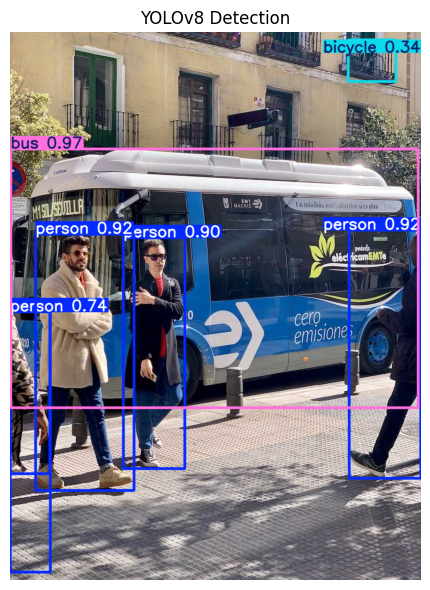

In [18]:
results = model('bus.jpg')
for result in results:
    annotated = result.plot()  # BGR 배열 반환

plt.figure(figsize=(10, 6))
plt.imshow(annotated[:, :, ::-1])  # BGR → RGB 변환
plt.title("YOLOv8 Detection")
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Part 3: YOLOv8 실전 활용 + 최적화

### 3.1 실시간 웹캠 추론 파이프라인

- `stream=True`: 메모리 효율적인 제너레이터 방식
- `q` 키를 누르면 종료

In [ ]:
# 실습자료/05.02.01.Webcam-Detection.py

### 3.2 탐지 결과 필터링

- **Confidence Threshold**: `model.predict(conf=0.5)` — 낮은 확률의 거짓 양성 제거
- **특정 클래스만 탐지**: `classes` 매개변수로 원하는 클래스 인덱스 지정
- **NMS (Non-Maximum Suppression)**: 같은 객체에 여러 박스 생성 시, 가장 높은 점수만 남기고 제거

In [19]:
# 사람(0)과 자동차(2)만 탐지, 신뢰도 0.5 이상만 표시
results = model.predict('bus.jpg', classes=[0, 2], conf=0.5)

print("=== 필터링 결과 (사람 + 자동차만) ===")
for result in results:
    for box in result.boxes:
        label = model.names[int(box.cls[0])]
        conf = box.conf[0]
        print(f"  {label}: conf={conf:.2f}")


image 1/1 /home/jshim/Desktop/workspace/robot_project/bus.jpg: 640x480 4 persons, 800.1ms
Speed: 1.4ms preprocess, 800.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
=== 필터링 결과 (사람 + 자동차만) ===
  person: conf=0.92
  person: conf=0.92
  person: conf=0.90
  person: conf=0.74


### 3.3 FPS 측정 — 로봇 구동 환경 성능 확인

로봇 실시간 제어에는 최소 **15~30 FPS 이상**이 필요합니다.
`imgsz` 를 낮추면 속도가 올라가지만 소형 객체 탐지 성능이 떨어집니다.

In [20]:
model = YOLO('yolov8n.pt')
image = cv2.imread('bus.jpg')

N = 30  # 측정 횟수
start = time.time()

for _ in range(N):
    results = model.predict(image, verbose=False)

elapsed = time.time() - start
fps = N / elapsed

print(f"평균 FPS: {fps:.1f} (총 {elapsed:.2f}초 / {N}회)")
print(f"실시간 제어 적합 여부: {'✓ 적합 (15FPS 이상)' if fps >= 15 else '✗ 부적합 (너무 느림)'}")

평균 FPS: 25.0 (총 1.20초 / 30회)
실시간 제어 적합 여부: ✓ 적합 (15FPS 이상)


In [21]:
# imgsz 축소로 속도 향상 비교
start = time.time()
for _ in range(N):
    results = model.predict(image, imgsz=320, verbose=False)
elapsed_small = time.time() - start
fps_small = N / elapsed_small

print(f"\nimgsz=640 (기본): {fps:.1f} FPS")
print(f"imgsz=320 (축소): {fps_small:.1f} FPS")
print(f"속도 향상 배율: {fps_small / fps:.1f}x")


imgsz=640 (기본): 25.0 FPS
imgsz=320 (축소): 46.6 FPS
속도 향상 배율: 1.9x


---
## Part 5: 칼만 필터 — 원리 깊이 이해하기

### 5.1 상태(State) 벡터

칼만 필터가 추적하는 것: 위치 $p$와 속도 $v$

$$\vec{x} = \begin{bmatrix} p \\ v \end{bmatrix}$$

- 위치만 알면 "다음에 어디 있을지" 모름. 속도를 함께 알면 **예측 가능**.
- 둘 다 정확한 값을 모름 → 칼만 필터가 추정
    - **추정값의 중심** = $\hat{x}_k$ (가장 그럴듯한 값)
    - **추정값의 불확실성** = $P_k$ (얼마나 모르는지)

### 5.2 공분산 행렬 $P_k$ — 불확실성 표현

$$P_k = \begin{bmatrix} \sigma_p^2 & \sigma_{pv} \\ \sigma_{vp} & \sigma_v^2 \end{bmatrix}$$

| 원소 | 의미 |
|:-----|:-----|
| $\sigma_p^2$ (대각) | 위치를 얼마나 모르는가 |
| $\sigma_v^2$ (대각) | 속도를 얼마나 모르는가 |
| $\sigma_{pv}$ (비대각) | 위치 오차와 속도 오차의 상관관계 |

- **초기값 $P_0$**: 실제 오차가 아닌 **"얼마나 모른다고 가정할지"** 를 설계자가 결정
- 잘못 설정해도 몇 스텝 안에 자동 수렴. 불확실하면 **크게** 설정하는 것이 안전

In [3]:
# "초기 위치는 ±5m, 속도는 ±2m/s 정도로 불확실하다" 고 가정
# 분산 = 표준편차² → 5² = 25, 2² = 4
# 왜쓰냐? 센서값도 내가 운동방정식 세워서 예측한 값도 못믿겠어서 쓴다.
# 그래서 최종값 = 내짐작 + 칼만게인(센서값-내짐작)
# 칼만게인 = 예측오차 / (예측오차 + 센서오차)
# 센서 오차가 커지면 칼만게인이 0으로 수렴, 센서를 믿을 수없다
# 예측오차가 커지면 칼만게인이 1로 수렴해 센서 의존적 

P_0 = np.array([[25, 0],
                [0,  4]], dtype=float)

print("초기 공분산 행렬 P_0:")
print(P_0)

초기 공분산 행렬 P_0:
[[         25           0]
 [          0           4]]


### 5.3 노이즈 행렬 Q와 R

| | $Q_k$ (프로세스 노이즈) | $R_k$ (센서 노이즈) |
|:---|:---|:---|
| **의미** | 내 예측이 얼마나 틀릴 수 있는가 | 센서가 얼마나 부정확한가 |
| **비유** | "바람이 세서 예측이 빗나갈 수 있어" | "GPS가 ±10m 오차야" |
| **적용 단계** | Predict | Update |

- $R_k$ 크기는 센서 개수에 따라 결정: GPS 1개 → $1 \times 1$, YOLO 중심좌표 $(x, y)$ → $2 \times 2$

In [4]:
# R: 센서를 고정하고 반복 측정 → 분산으로 계산 (비교적 쉬움)
np.random.seed(42)
gps_readings = np.random.normal(loc=0.0, scale=2.5, size=1000)  # ±2.5m 오차 시뮬레이션
R = np.var(gps_readings)
print(f"GPS 노이즈 분산 R = {R:.4f} (표준편차 ≈ {np.sqrt(R):.2f}m)")

GPS 노이즈 분산 R = 5.9869 (표준편차 ≈ 2.45m)


### 5.4 Predict 단계 — "다음에 어디 있을까?"

$$\hat{x}_k^- = A \hat{x}_{k-1} + B u_k$$
$$P_k^- = A P_{k-1} A^T + Q_k$$

- **$A$ (상태 전이 행렬)**: 등속 운동 가정 $p_k = p_{k-1} + v_{k-1} \cdot \Delta t$

$$A = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}$$

- **$B u_k$ (제어 입력)**: 가속도 명령 $a$가 있다면 위치·속도에 반영
- **핵심**: Predict 후 $P_k^-$ 가 커짐 — 예측만으로는 점점 불확실해짐

### 5.5 Update 단계 — "센서가 뭐라 했지?"

**센서 행렬 $C$**: 상태벡터 $[p, v]^T$ 중 센서가 측정 가능한 성분만 추출
$$C = \begin{bmatrix} 1 & 0 \end{bmatrix} \quad \text{(위치만 측정 가능)}$$

**Innovation**: 예측 측정값 vs 실제 측정값의 차이
$$\text{Innovation} = y_k - C\hat{x}_k^-$$

**칼만 게인 $K_k$**: 예측과 센서 중 무엇을 더 믿을지
$$K_k = P_k^- C^T (C P_k^- C^T + R_k)^{-1}$$

| 상황 | $K_k$ 값 | 의미 |
|:-----|:---------|:-----|
| 예측이 불확실 ($P^- \gg R$) | $K_k \to 1$ | 센서를 거의 100% 신뢰 |
| 센서가 부정확 ($P^- \ll R$) | $K_k \to 0$ | 예측을 거의 100% 신뢰 |

**보정 및 불확실성 감소**:
$$\hat{x}_k = \hat{x}_k^- + K_k(y_k - C \hat{x}_k^-)$$
$$P_k = (I - K_k C) P_k^-$$

### 5.6 칼만 필터 구현 실습

1차원 위치-속도 칼만 필터를 클래스로 구현합니다.
`predict()` 와 `update()` 메서드를 완성하세요.

In [13]:
class KalmanFilter1D:
    """
    1D 위치-속도 칼만 필터
    상태벡터: [position, velocity]
    """
    def __init__(self, dt=0.1, process_noise=1.0, sensor_noise=5.0):
        self.dt = dt

        # 상태 전이 행렬 A (등속 운동 모델)
        self.A = np.array([[1, dt],
                           [0,  1]], dtype=float)

        # 제어 행렬 B (가속도 입력)
        self.B = np.array([[0.5 * dt**2],
                           [dt]], dtype=float)

        # 센서 행렬 C (위치만 측정)
        self.C = np.array([[1, 0]], dtype=float)

        # 프로세스 노이즈 Q
        self.Q = np.eye(2) * process_noise

        # 센서 노이즈 R
        self.R = np.array([[sensor_noise]], dtype=float)

        # 초기 상태 및 공분산
        self.x = np.zeros((2, 1))   # [position, velocity]
        self.P = np.eye(2) * 100    # 초기 불확실성 (크게 설정)

    def predict(self, u=0.0):
        """
        Predict 단계: 운동 모델로 다음 상태 예측
        u: 제어 입력 (가속도)
        반환: 예측된 위치
        """
        # TODO: 여기에 구현하세요
        # 힌트 1: self.x = self.A @ self.x + self.B * u
        # 힌트 2: self.P = self.A @ self.P @ self.A.T + self.Q
        self.x = self.A @ self.x + self.B * u
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x[0, 0]   # 예측된 위치 반환

    def update(self, z):
        """
        Update 단계: 실제 센서 측정값으로 상태 보정
        z: 실제 측정값 (위치)
        반환: 보정된 위치
        """
        # TODO: 여기에 구현하세요
        # 힌트 1: z = np.array([[z]])
        # 힌트 2: innovation = z - self.C @ self.x (예측 측정값과 실측값의 차이)
        # 힌트 3: S = self.C @ self.P @ self.C.T + self.R (Innovation 공분산)
        # 힌트 4: K = self.P @ self.C.T @ np.linalg.inv(S) (칼만 게인)
        # 힌트 5: self.x = self.x + K @ innovation
        # 힌트 6: self.P = (np.eye(2) - K @ self.C) @ self.P
        z = np.array([[z]])
        innovation = z - self.C @ self.x
        S = self.C @ self.P @ self.C.T + self.R
        K = self.P @ self.C.T @ np.linalg.inv(S)
        self.x = self.x + K @ innovation
        self.P = (np.eye(2) - K @ self.C) @ self.P
        return self.x[0, 0]   # 보정된 위치 반환

    def get_state(self):
        """현재 상태 [position, velocity] 반환"""
        return self.x[0, 0], self.x[1, 0]

In [32]:
# 구현 테스트 — 노이즈가 있는 GPS 데이터로 필터 성능 확인
np.random.seed(42)

dt = 0.1
N = 100  # 시뮬레이션 스텝 수
kf = KalmanFilter1D(dt=dt, process_noise=0.1, sensor_noise=5.0)

In [33]:
# 실제 물체: 등속 운동 (초기 위치=0, 속도=1.0m/s)
true_positions = [i * dt * 1.0 for i in range(N)]

In [34]:
# GPS 노이즈 시뮬레이션 (±2.0m 오차)
gps_measurements = [p + np.random.normal(0, 2.0) for p in true_positions]

In [35]:
predicted_positions = []
filtered_positions = []

for i, z in enumerate(gps_measurements):
    pred_pos = kf.predict()
    filt_pos = kf.update(z)
    predicted_positions.append(pred_pos)
    filtered_positions.append(filt_pos)

In [36]:
# 결과 출력
print(f"{'t':>4} | {'실제':>6} | {'GPS':>8} | {'필터':>8} | {'오차(GPS)':>10} | {'오차(필터)':>10}")
print("-" * 65)
for i in range(0, N):
    gps_err = abs(gps_measurements[i] - true_positions[i])
    filt_err = abs(filtered_positions[i] - true_positions[i])
    print(f"{i:>4} | {true_positions[i]:>6.2f} | {gps_measurements[i]:>8.2f} | {filtered_positions[i]:>8.2f} | {gps_err:>10.2f} | {filt_err:>10.2f}")

   t |     실제 |      GPS |       필터 |    오차(GPS) |     오차(필터)
-----------------------------------------------------------------
   0 |   0.00 |     0.99 |     0.95 |       0.99 |       0.95
   1 |   0.10 |    -0.18 |     0.34 |       0.28 |       0.24
   2 |   0.20 |     1.50 |     0.85 |       1.30 |       0.65
   3 |   0.30 |     3.35 |     2.09 |       3.05 |       1.79
   4 |   0.40 |    -0.07 |     1.30 |       0.47 |       0.90
   5 |   0.50 |     0.03 |     0.78 |       0.47 |       0.28
   6 |   0.60 |     3.76 |     2.01 |       3.16 |       1.41
   7 |   0.70 |     2.23 |     2.23 |       1.53 |       1.53
   8 |   0.80 |    -0.14 |     1.49 |       0.94 |       0.69
   9 |   0.90 |     1.99 |     1.70 |       1.09 |       0.80
  10 |   1.00 |     0.07 |     1.23 |       0.93 |       0.23
  11 |   1.10 |     0.17 |     0.90 |       0.93 |       0.20
  12 |   1.20 |     1.68 |     1.11 |       0.48 |       0.09
  13 |   1.30 |    -2.53 |     0.08 |       3.83 |       1.22
  14

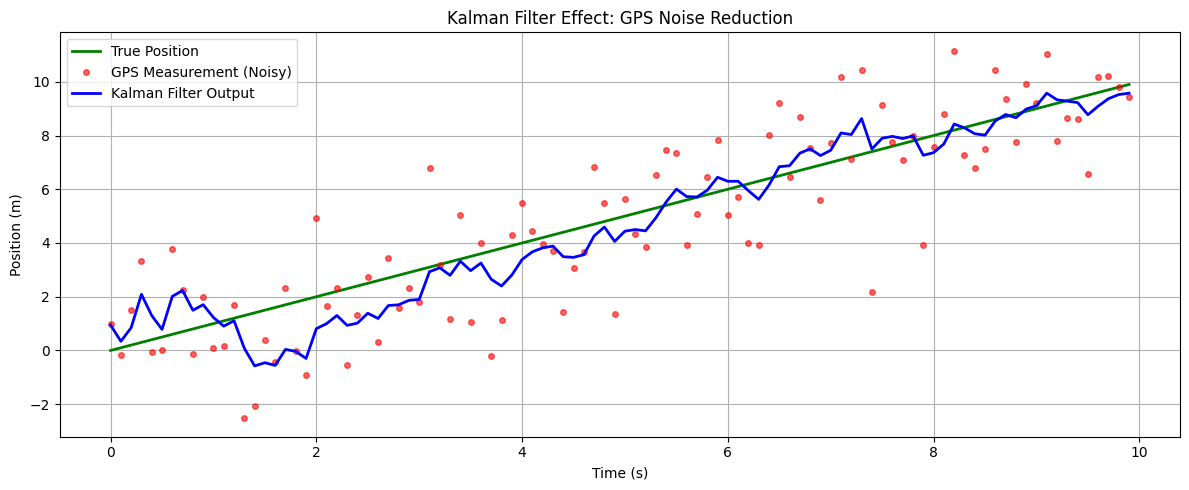

In [37]:
# 칼만 필터 결과 시각화
plt.figure(figsize=(12, 5))
t = [i * dt for i in range(N)]
plt.plot(t, true_positions,    'g-',  label='True Position', linewidth=2)
plt.plot(t, gps_measurements,  'r.',  label='GPS Measurement (Noisy)', alpha=0.6, markersize=8)
plt.plot(t, filtered_positions,'b-',  label='Kalman Filter Output', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Kalman Filter Effect: GPS Noise Reduction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.7 YOLO + 칼만 필터 연동

YOLO 탐지 결과의 **중심점 (cx, cy)**에 칼만 필터를 적용하여 떨림을 안정화합니다.
05.02.02.Webcam-Kalman.py